In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np

from nexuskan import *
from nexuskan import KAN
from nexuskan import nexusKAN

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# grad test

$x_1 x_3 + x_2 x_5 + x_4$

in: 5, out: 2

In [58]:
def some_func_to_add_dim(x, out_dim):
    x_res = torch.unsqueeze(x, dim=2)
    for i in range(out_dim - 1):
        x_res = torch.concat((x_res, torch.unsqueeze(x * 2., dim=2)), dim=2)
    
    return x_res

In [59]:
batch = 4
in_dim = 5
out_dim = 2

y_true = torch.tensor([[ -6., -28.],
                       [-21., -79.],
                       [36.,  138.],
                       [11.,  42.]]) # (batch, out_dim)
criterion = nn.MSELoss()

mask = torch.tensor([[0.9, -0.5], 
                     [-0.6, 0.6], 
                     [0.8, -0.5], 
                     [-0.9, -0.6],
                     [-0.6, 0.8]]).requires_grad_(True) # (in_dim, in_dim // 2)

x = torch.tensor([[2.0, 2.0, -2.0, 2.0, -2.0],
                  [3.0, -3.0, -3.0, -3.0, 3.0],
                  [4.0, -4.0, 4.0, 4.0, -4.0],
                  [4.0, -1.0, 2.0, 1.0, -2.0]]).requires_grad_(True) # (batch, in_dim)

y = some_func_to_add_dim(x, out_dim=out_dim) # (batch, in_dim, out_dim)

tau = 0.1
hard_mask = torch.sigmoid(mask / tau) # (in_dim, in_dim // 2)

# --- signs with threshold ---
# epsilon = 1e-8
# sign_data = torch.sign(y + epsilon) # (batch, in_dim, out_dim)
# mask_expanded = hard_mask[None, :, None, :] # (1, in_dim, 1, groups)
# sign_data_expanded = sign_data.unsqueeze(-1) # (batch, in_dim, out_dim, 1)
# selected_signs = torch.where(mask_expanded > 0.5, sign_data_expanded, 1.0) # (batch, in_dim, out_dim, in_dim // 2)
# final_sign = torch.prod(selected_signs, dim=1) # (batch, out_dim, in_dim // 2)
# masked_y_for_prod = torch.pow(torch.abs(y.unsqueeze(-1)), hard_mask[None, :, None, :]) # (batch, in_dim, out_dim, in_dim // 2)

# --- signs with linear representation ---
masked_y_for_prod = 1 - hard_mask[None, :, None, :] + hard_mask[None, :, None, :] * y.unsqueeze(-1) # (batch, in_dim, out_dim, in_dim // 2)
y_prod = torch.prod(masked_y_for_prod, dim=1) # (batch, out_dim, in_dim // 2)

masked_y_for_sum = y * (1. - torch.sum(hard_mask, dim=1)[:, None]) # (batch, in_dim, out_dim)

y = torch.sum(masked_y_for_sum, dim=1) + torch.sum(y_prod, dim=2)

print("y.size() =", y.size())
print(y)
loss = criterion(y, y_true)
loss.backward()
print(mask.grad)



y.size() = torch.Size([4, 2])
tensor([[ -5.9285, -27.7758],
        [-20.7027, -76.5018],
        [ 36.2673, 140.2303],
        [ 10.9046,  41.8166]], grad_fn=<AddBackward0>)
tensor([[ 1.2219e-03,  9.8583e+00],
        [-3.6339e+00,  6.6149e-01],
        [ 3.4755e-03,  2.8841e+01],
        [ 4.8847e-01,  1.0591e+01],
        [-1.0303e+01,  8.8898e-02]])


# **Dataset** $y = x_0 x_2 +  x_4 \sin{2 \pi x_3} + x_2$ and 2 learnable prod group

In [60]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 5) + start_range
# y = torch.sin(2 * torch.pi * x[:, 0]) + torch.sin(2 * torch.pi * x[:, 1])
y = x[:, 0] * x[:, 2] + torch.sin(2 * torch.pi * x[:, 3]) * x[:, 4] + x[:, 1]
# y = x[:, 0] * x[:, 2] + x[:, 1]
# y_class = torch.where(y > 0.5, 1.0, 0.0)
dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    # 'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
    # 'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 5]), torch.Size([1000, 1]))

In [61]:
model = nexusKAN(width=[5, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

checkpoint directory created: ./model
saving model version 0.0
Error in callback <function flush_figures at 0x7ca479b18180> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=0.1)

In [ ]:
def get_tau(step, total_steps, tau_start=2.0, tau_end=0.01):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

In [ ]:
criterion = nn.MSELoss()

batch_size = 512 # dataset['train_input'].shape[0]
epochs = 1000

grid_update_freq = 200

for epoch in range(epochs):
    batches = dataset['train_input'].shape[0] // batch_size
    for batch_idx in range(batches):
        if batch_idx == batches - 1:
            indices = torch.arange(batch_idx * batch_size, dataset['train_input'].shape[0])
        else:
            indices = torch.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
        
        batch_x = dataset['train_input'][indices]
        batch_y = dataset['train_label'][indices]
        
        if epoch % grid_update_freq == 0:
            model.update_grid(batch_x)
        # if (epoch + 1) % grid_update_freq == 0:
        #     for param_group in optimizer.param_groups:
        #         param_group['lr'] *= 0.8
                
        new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
        for module in model.modules():
            if isinstance(module, NexusKANLayer):
                module.tau = new_tau

        
        outputs = model(batch_x)
        
        train_loss = criterion(outputs, batch_y)
        
        lamb = 0.00001
        l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
        loss = train_loss + lamb * l1_reg
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        test_outputs = model(dataset['test_input'])
        test_loss = criterion(test_outputs, dataset['test_label'])
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, reg: {l1_reg:.4f}')

Epoch [10/1000], Train Loss: 0.3187, Test Loss: 0.3060, reg: 110.9258
Epoch [20/1000], Train Loss: 0.2756, Test Loss: 0.2671, reg: 118.6067
Epoch [30/1000], Train Loss: 0.2711, Test Loss: 0.2686, reg: 120.1259
Epoch [40/1000], Train Loss: 0.2670, Test Loss: 0.2655, reg: 123.0436
Epoch [50/1000], Train Loss: 0.2649, Test Loss: 0.2671, reg: 123.6165
Epoch [60/1000], Train Loss: 0.2640, Test Loss: 0.2662, reg: 124.5664
Epoch [70/1000], Train Loss: 0.2634, Test Loss: 0.2670, reg: 125.5062
Epoch [80/1000], Train Loss: 0.2625, Test Loss: 0.2662, reg: 127.0517
Epoch [90/1000], Train Loss: 0.2602, Test Loss: 0.2647, reg: 129.5654
Epoch [100/1000], Train Loss: 0.2113, Test Loss: 0.1988, reg: 134.7119
Epoch [110/1000], Train Loss: 0.1183, Test Loss: 0.1253, reg: 140.1336
Epoch [120/1000], Train Loss: 0.0585, Test Loss: 0.0557, reg: 151.8703
Epoch [130/1000], Train Loss: 0.0147, Test Loss: 0.0144, reg: 148.8607
Epoch [140/1000], Train Loss: 0.0062, Test Loss: 0.0071, reg: 152.8046
Epoch [150/1000

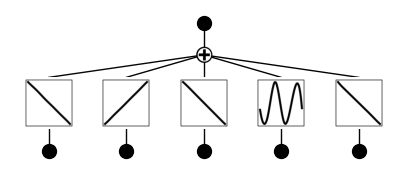

In [ ]:
model.plot()

In [ ]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[ 1.3112e+00,  7.2052e-01,  4.0759e-01,  6.3297e-02, -6.9492e-02,
          -1.3125e-01, -7.9175e-03,  2.5845e-03]],

        [[-1.7849e+00, -1.3860e+00, -6.6246e-01, -1.8773e-01,  2.2796e-01,
           4.3063e-01,  6.2075e-01,  5.2986e-01]],

        [[ 1.3409e+00,  9.5636e-01,  4.3605e-01,  7.6219e-02, -1.4172e-01,
          -2.1443e-01, -1.9973e-01,  3.1275e-03]],

        [[ 3.0595e+00, -4.8333e-01, -8.4864e-01,  1.4773e+00, -1.3165e+00,
           4.3479e-01,  1.1103e+00, -5.4682e+00]],

        [[ 1.6612e+00,  8.1083e-01,  4.1879e-01,  1.1066e-01, -8.2183e-02,
          -9.3971e-02, -2.6204e-02,  3.1117e-01]]], device='cuda:0')
act_fun.0.scale_base tensor([[-1.2633e+00],
        [ 9.4045e-01],
        [-1.2728e+00],
        [-4.3539e-06],
        [-1.5160e+00]], device='cuda:0')
act_fun.0.scale_sp tensor([[0.7720],
        [0.5513],
        [0.7411],
        [1.5380],
        [0.8202]], device='cuda:0')
act_fun.0.logits tensor([[[ 1.6744e-04,  3.4187e+00,

# **Dataset** $y = \frac{\frac{x_0}{x_1} + \frac{x_2}{x_3}}{\frac{x_4}{x_5} + \frac{x_6}{x_7}}$ 

In [108]:
end_range = 1.0
start_range = 0.2
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 8) + start_range

y = (x[:, 0] / x[:, 1] + x[:, 2] / x[:, 3]) / (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7])
# y = x[:, 0] / (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7])
# y = (x[:, 4] / x[:, 5] + x[:, 6] / x[:, 7]) / x[:, 0]

dataset = {
    'train_input': x[:1000],
    'train_label': y[:1000].unsqueeze(dim=1),
    # 'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y[-200:].unsqueeze(dim=1),
    # 'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
dataset['train_input'].shape, dataset['train_label'].shape

(torch.Size([1000, 8]), torch.Size([1000, 1]))

checkpoint directory created: ./model
saving model version 0.0


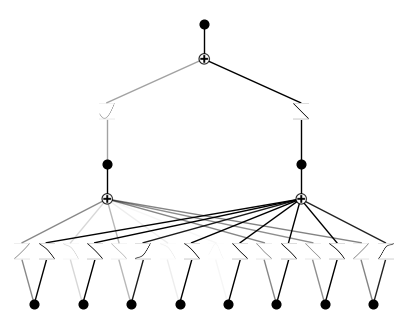

In [109]:
model = nexusKAN(width=[8, 2, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [110]:
optimizer = optim.Adam(model.parameters(), lr=0.1)

In [111]:
def get_tau(step, total_steps, tau_start=2.0, tau_end=0.1):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

In [112]:
def get_reg_lambda(step, total_steps, tau_start=0.0001, tau_end=0.01):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

In [113]:
criterion = nn.MSELoss()

batch_size = 512 # dataset['train_input'].shape[0]
epochs = 2000

grid_update_freq = 200

for epoch in range(epochs):
    batches = dataset['train_input'].shape[0] // batch_size
    for batch_idx in range(batches):
        if batch_idx == batches - 1:
            indices = torch.arange(batch_idx * batch_size, dataset['train_input'].shape[0])
        else:
            indices = torch.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
        
        batch_x = dataset['train_input'][indices]
        batch_y = dataset['train_label'][indices]
        
        # if epoch % grid_update_freq == 0:
        #     model.update_grid(batch_x)
        if (epoch + 1) % grid_update_freq == 0:
            for param_group in optimizer.param_groups:
                param_group['lr'] *= 0.8
                
        new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.5)
        for module in model.modules():
            if isinstance(module, NexusKANLayer):
                module.tau = new_tau

        outputs = model(batch_x)
        train_loss = criterion(outputs, batch_y)
        
        entropy_total = 0.0
        num_layers = 0
        for module in model.modules():
            if isinstance(module, NexusKANLayer):
                probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                eps = 1e-8
                entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                entropy_total += entropy_i.mean()
                num_layers += 1
        if num_layers > 0:
            entropy_avg = entropy_total / num_layers
        else:
            entropy_avg = 0.0
        
        lamb_ent = 1e-1 # get_reg_lambda(epoch, epochs, tau_start=0.000001, tau_end=0.00001)
        lamb = 1e-6 # get_reg_lambda(epoch, epochs, tau_start=0.000001, tau_end=0.00001)
        
        l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
        loss = train_loss + lamb * l1_reg + lamb_ent * entropy_avg
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        test_outputs = model(dataset['test_input'])
        test_loss = criterion(test_outputs, dataset['test_label'])
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, reg: {l1_reg:.4f}')

Epoch [10/2000], Train Loss: 0.6755, Test Loss: 0.6232, reg: 276.5922
Epoch [20/2000], Train Loss: 0.1972, Test Loss: 0.2029, reg: 307.8476
Epoch [30/2000], Train Loss: 0.0902, Test Loss: 0.1038, reg: 324.1327
Epoch [40/2000], Train Loss: 0.0603, Test Loss: 0.0786, reg: 333.0051
Epoch [50/2000], Train Loss: 0.0423, Test Loss: 0.0574, reg: 341.0281
Epoch [60/2000], Train Loss: 0.0390, Test Loss: 0.0512, reg: 347.3148
Epoch [70/2000], Train Loss: 0.0358, Test Loss: 0.0492, reg: 353.9281
Epoch [80/2000], Train Loss: 0.0334, Test Loss: 0.0454, reg: 360.7701
Epoch [90/2000], Train Loss: 0.0311, Test Loss: 0.0426, reg: 368.7117
Epoch [100/2000], Train Loss: 0.0287, Test Loss: 0.0401, reg: 376.5805
Epoch [110/2000], Train Loss: 0.0260, Test Loss: 0.0380, reg: 385.7072
Epoch [120/2000], Train Loss: 0.0238, Test Loss: 0.0348, reg: 394.7915
Epoch [130/2000], Train Loss: 0.0218, Test Loss: 0.0322, reg: 403.0704
Epoch [140/2000], Train Loss: 0.0199, Test Loss: 0.0312, reg: 410.8215
Epoch [150/2000

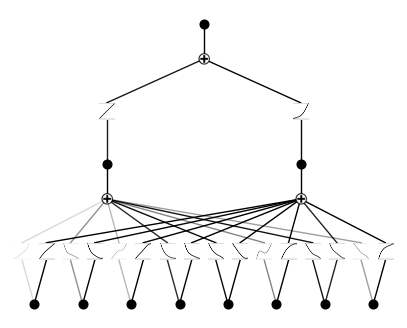

In [114]:
model.plot()

In [115]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

act_fun.0.coef tensor([[[-3.6346e-03, -9.3966e-04,  8.2994e-04, -1.2894e+00, -5.7422e-01,
          -1.9267e-02,  9.0425e-01,  3.8240e-01],
         [-1.8913e-04,  1.2838e-03,  9.1044e-04, -3.0039e+00, -1.3331e+00,
          -6.2798e-02,  5.8685e-01,  1.9127e+00]],

        [[-2.4209e-04, -2.8629e-03, -3.2680e-03,  4.2027e+00,  8.7702e-01,
           6.8426e-01,  3.1662e-01, -5.0046e-02],
         [ 3.9636e-04, -2.5108e-03,  9.3336e-05,  5.6541e-01, -1.2247e+00,
          -9.2734e-01, -5.1467e-01,  5.9907e-01]],

        [[-1.1565e-03,  2.1967e-04, -2.9990e-03, -6.1758e-05,  3.7961e-01,
           7.7506e-01, -2.1163e-01,  3.2946e+00],
         [-4.6268e-04,  5.4385e-05,  3.6048e-04, -2.5939e+00, -1.2288e+00,
          -4.5245e-01,  7.7856e-01,  7.8449e-02]],

        [[-6.1449e-04,  9.0095e-04,  2.1204e-04,  5.0786e+00,  1.4897e+00,
           7.0367e-01,  4.6022e-01,  2.7688e-01],
         [-1.5346e-04, -2.8526e-03,  1.6316e-04,  2.1800e+00, -1.1343e+00,
          -8.4115e-01, -3.277

In [116]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        print(probs)

tensor([[[9.9938e-01, 3.0179e-09, 4.8132e-09, 1.4723e-08, 6.1751e-04],
         [2.1847e-08, 4.7677e-10, 9.9999e-01, 1.0618e-05, 7.1013e-07]],

        [[1.0000e+00, 7.9232e-11, 1.3699e-10, 4.1347e-10, 3.6067e-07],
         [3.4673e-05, 3.6900e-05, 3.7355e-01, 3.6563e-01, 2.6075e-01]],

        [[1.0000e+00, 1.8721e-06, 4.1744e-11, 1.0471e-11, 3.6386e-09],
         [2.9670e-11, 1.0000e+00, 9.4304e-11, 6.0961e-11, 1.4401e-11]],

        [[8.3755e-01, 1.1395e-07, 3.8078e-07, 1.2683e-07, 1.6245e-01],
         [3.3229e-01, 4.3648e-01, 1.8527e-06, 5.1846e-05, 2.3117e-01]],

        [[1.0000e+00, 6.7491e-11, 5.7258e-09, 1.5331e-11, 8.0471e-09],
         [2.3428e-06, 7.5543e-07, 2.5916e-06, 9.8140e-01, 1.8597e-02]],

        [[1.0000e+00, 2.9815e-10, 7.8991e-10, 3.4214e-09, 9.7763e-08],
         [1.0000e+00, 6.2910e-08, 1.2457e-06, 5.6653e-10, 1.3863e-06]],

        [[1.0000e+00, 1.9799e-11, 8.9843e-12, 1.1483e-11, 3.0273e-10],
         [4.4306e-01, 1.8841e-02, 7.6220e-06, 4.4657e-01, 9.1520e